# HMM (Weekly Volatility) — Consolidated Results


# US SP500 Regime Prediction

In [12]:
# dependence
# %pip install yfinance pandas numpy matplotlib hmmlearn scikit-learn -q

In [13]:
import numpy as np
import pandas as pd
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt
from scipy.stats import norm

from data_preprocessing import data_adapter as adapter

In [14]:
# get data
adapter = adapter.YFinanceAdapter()
data= adapter.get_data(tickers="^GSPC", start_date="2019-01-01",end_date="2026-01-01")

Loading data from cache...


In [15]:
data['return'] = data['Adj Close'].pct_change()
data = data.dropna()

## Train model

In [16]:
train = data.loc["2019-01-01":"2023-12-31"].copy()
test  = data.loc["2024-01-01":"2025-12-31"].copy()

X_train = train['return'].values.reshape(-1, 1)
X_test  = test['return'].values.reshape(-1, 1)

### 1. 2 states test

In [17]:
# define model: bear, bull
model = GaussianHMM(
    n_components=2, 
    covariance_type="full", 
    n_iter=1000,
    random_state=42
)

model.fit(X_train)

e:\Code\Anaconda\envs\hwenv\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


GaussianHMM(covariance_type='full', n_components=2, n_iter=1000,
            random_state=42)

Adapt filtering

In [18]:
test_states = []

_, current_prob = model.score_samples(X_train[-10:])  
current_prob = current_prob[-1]

means = model.means_.flatten()
vars_ = model.covars_.flatten()

for t in range(len(X_test)):
    
    pred_prob = np.dot(current_prob, model.transmat_)

    obs = X_test[t][0]
    
    likelihood = np.array([
        norm.pdf(obs, means[i], np.sqrt(vars_[i]))
        for i in range(model.n_components)
    ])

    current_prob = pred_prob * likelihood
    current_prob /= current_prob.sum()

    state = np.argmax(current_prob)
    test_states.append(state)

test['state'] = test_states

In [19]:
train_states = model.predict(X_train)

state_means = []
for i in range(model.n_components):
    state_means.append(X_train[train_states == i].mean())

state_means = np.array(state_means)
bull_state = np.argmax(state_means)

test['signal'] = test['state'].apply(lambda s: 1 if s == bull_state else 0)
test['strategy_return'] = test['signal'].shift(1) * test['return']
test['strategy_return'] = test['strategy_return'].fillna(0)
test['wealth_market']   = (1 + test['return']).cumprod()
test['wealth_strategy'] = (1 + test['strategy_return']).cumprod()

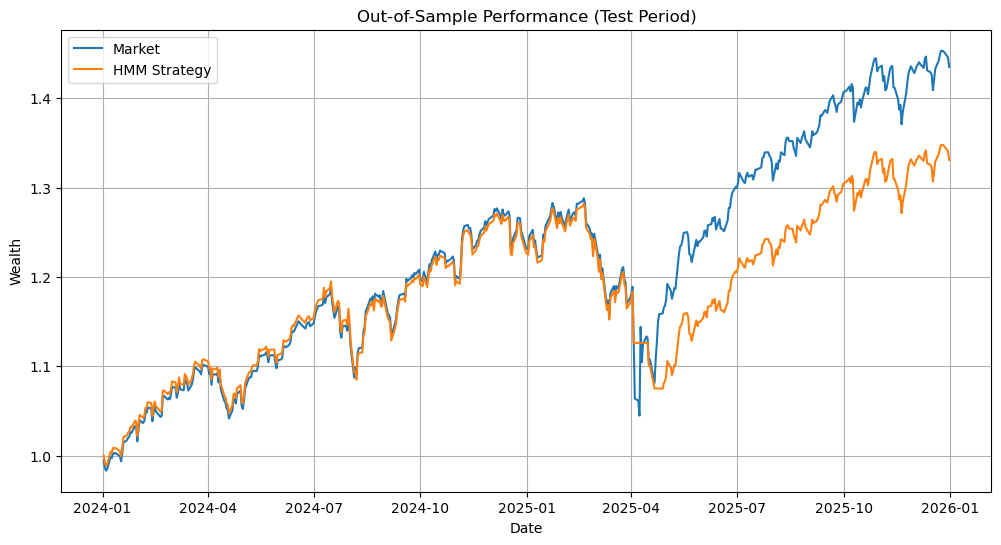

In [20]:

plt.figure(figsize=(12,6))

plt.plot(test.index, test['wealth_market'], label='Market')
plt.plot(test.index, test['wealth_strategy'], label='HMM Strategy')

plt.legend()
plt.title('Out-of-Sample Performance (Test Period)')
plt.xlabel('Date')
plt.ylabel('Wealth')
plt.grid(True)

plt.show()

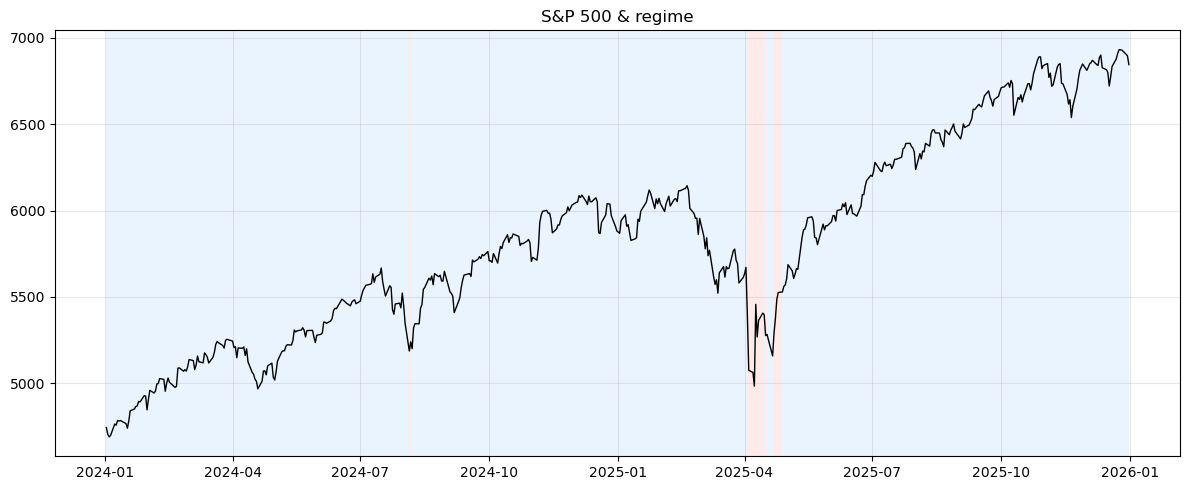

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = {0: "#ddeeff", 1: "#ffdddd",}  
for i in range(len(test) - 1):
    s = int(test["state"].iloc[i])
    ax.axvspan(test.index[i], test.index[i + 1], color=colors.get(s, "#eee"), alpha=0.6, lw=0)
ax.plot(test.index, test["Adj Close"], color="k", lw=1, zorder=3)
ax.set_title("S&P 500 & regime")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Information criteria sweep across n_states


In [8]:
import model_utils

In [9]:
ic_2=model_utils.hmm_pipeline(n_states=2,window=104,freq="W")
ic_3=model_utils.hmm_pipeline(n_states=3,window=104,freq="W")
ic_4=model_utils.hmm_pipeline(n_states=4,window=104,freq="W")
ic_5=model_utils.hmm_pipeline(n_states=5,window=104,freq="W")
ic_6=model_utils.hmm_pipeline(n_states=6,window=104,freq="W")

Loading data from cache...
Loading data from cache...
Loading data from cache...
Loading data from cache...
Loading data from cache...


Model is not converging.  Current: -1837.0282882153754 is not greater than -1828.4285768801722. Delta is -8.59971133520321
Model is not converging.  Current: -1836.3370364708517 is not greater than -1827.7340944492819. Delta is -8.602942021569788
Model is not converging.  Current: -1849.3969663391222 is not greater than -1842.6365237867528. Delta is -6.760442552369341


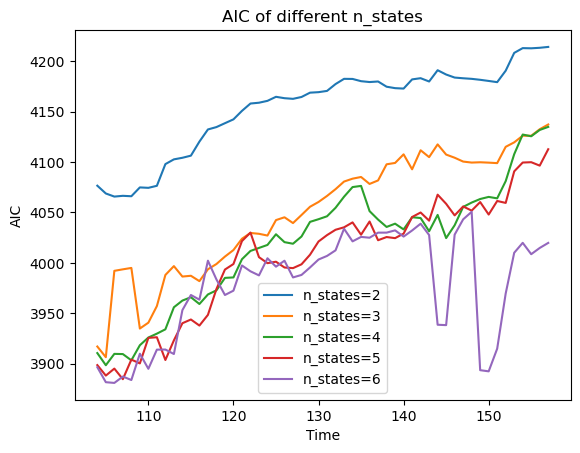

In [10]:
#draw ic-df change based on column name
import matplotlib.pyplot as plt
plt.plot(ic_2.index, ic_2['AIC'], label='n_states=2')
plt.plot(ic_3.index, ic_3['AIC'], label='n_states=3')
plt.plot(ic_4.index, ic_4['AIC'], label='n_states=4')
plt.plot(ic_5.index, ic_5['AIC'], label='n_states=5')
plt.plot(ic_6.index, ic_6['AIC'], label='n_states=6')
#name
plt.xlabel('Time')
plt.ylabel('AIC')
plt.title('AIC of different n_states')
plt.legend()
plt.show()

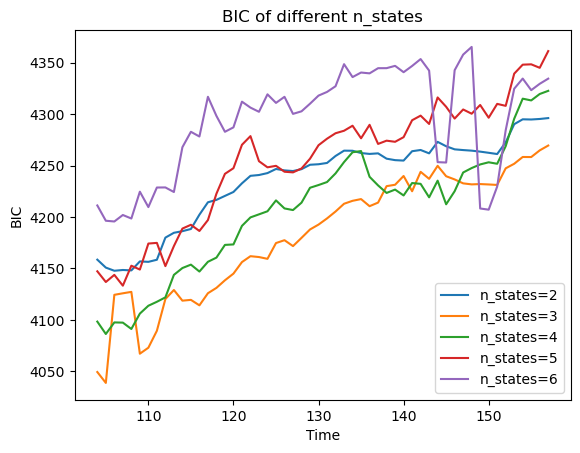

In [11]:
#BIC 
plt.plot(ic_2.index, ic_2['BIC'], label='n_states=2')
plt.plot(ic_3.index, ic_3['BIC'], label='n_states=3')
plt.plot(ic_4.index, ic_4['BIC'], label='n_states=4')
plt.plot(ic_5.index, ic_5['BIC'], label='n_states=5')
plt.plot(ic_6.index, ic_6['BIC'], label='n_states=6')
plt.xlabel('Time')
plt.ylabel('BIC')
plt.title('BIC of different n_states')
plt.legend()
plt.show()

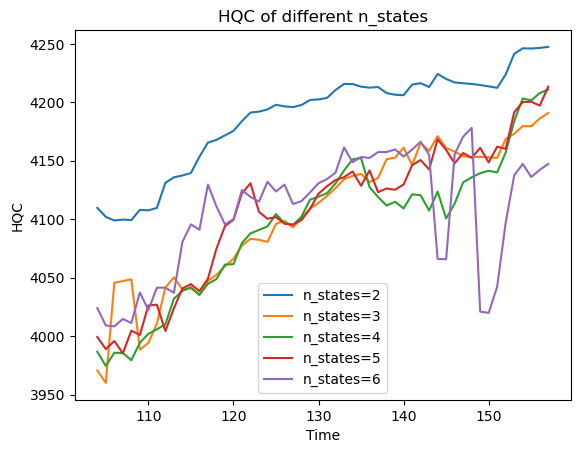

In [12]:
#HQC
plt.plot(ic_2.index, ic_2['HQC'], label='n_states=2')
plt.plot(ic_3.index, ic_3['HQC'], label='n_states=3')
plt.plot(ic_4.index, ic_4['HQC'], label='n_states=4')
plt.plot(ic_5.index, ic_5['HQC'], label='n_states=5')
plt.plot(ic_6.index, ic_6['HQC'], label='n_states=6')
plt.xlabel('Time')
plt.ylabel('HQC')
plt.title('HQC of different n_states')
plt.legend()
plt.show()



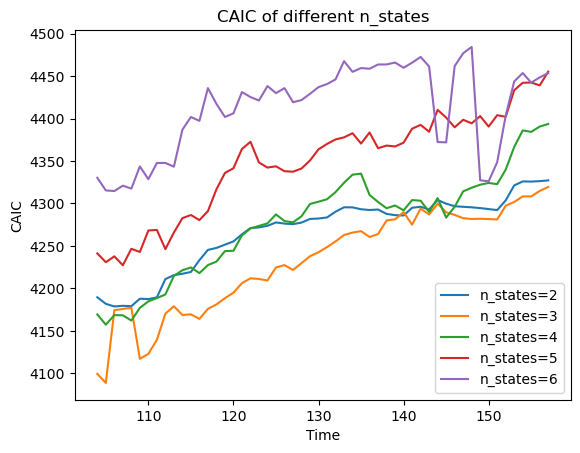

In [13]:
#CAIC
plt.plot(ic_2.index, ic_2['CAIC'], label='n_states=2')
plt.plot(ic_3.index, ic_3['CAIC'], label='n_states=3')
plt.plot(ic_4.index, ic_4['CAIC'], label='n_states=4')
plt.plot(ic_5.index, ic_5['CAIC'], label='n_states=5')
plt.plot(ic_6.index, ic_6['CAIC'], label='n_states=6')
plt.xlabel('Time')
plt.ylabel('CAIC')
plt.title('CAIC of different n_states')
plt.legend()
plt.show()


## Build model and backtest comparison


## Build model &compare

In [1]:
import pandas as pd 
import numpy as np

import model_utils
from data_preprocessing import data_adapter as adapter

In [2]:
start_date="2019-01-01"
test_date="2024-01-01"
end_date="2026-01-01"
freq="W"
n_states=3
window=104 #2 years （52*2）
random_seed=42

In [3]:
#forecast
train,test=model_utils.get_data(start_date,test_date,end_date,freq)
predicted_close = []
T = test.shape[0]-1 

model,log_likelihood=model_utils.build_hmm_and_score(train[-window:],n_states)

Loading data from cache...


In [4]:
import numpy as np
from hmmlearn.hmm import GaussianHMM


X_train = train[['Open','High','Low','Adj Close']].values
X_test = test[['Open','High','Low','Adj Close']].values
predicted_close = []

#initial fit
model,log_likelihood=model_utils.build_hmm_and_score(train[-window:],n_states)
# rolling forecast
for t in range(len(X_test)):
    if t < window:
        X_window = np.vstack([X_train[-(window-t):], X_test[:t]])
    else:
        X_window = X_test[t-window:t]
    
    model.fit(X_window)
    
    # predict test[t] close
    hidden_states = model.predict(X_window)
    # use last day Adj Close + HMM block match prediction
    O = X_window[-window:, :]
    logP_O = model.score(O)
    
    # find most similar historical block (train + past test)
    min_diff = np.inf
    T_star = None
    full_hist = np.vstack([X_train, X_test[:t]])
    for i in range(len(full_hist)-window):
        O_hist = full_hist[i:i+window, :]
        logP_hist = model.score(O_hist)
        diff = abs(logP_O - logP_hist)
        if diff < min_diff:
            min_diff = diff
            T_star = i
    
    # block match prediction
    O4_T = X_window[-1, 3]
    O4_Tstar_next = full_hist[T_star+window, 3]
    O4_Tstar = full_hist[T_star+window-1, 3]
    sign_term = np.sign(logP_O - model.score(full_hist[T_star:T_star+window, :]))
    O4_next = O4_T + (O4_Tstar_next - O4_Tstar) * sign_term
    predicted_close.append(O4_next)

Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'
Even though the 'covars_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'c'
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'
Even though the 'covars_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'c'


In [5]:
#add date to predicted_close
predicted_close=pd.Series(predicted_close,index=test.index)

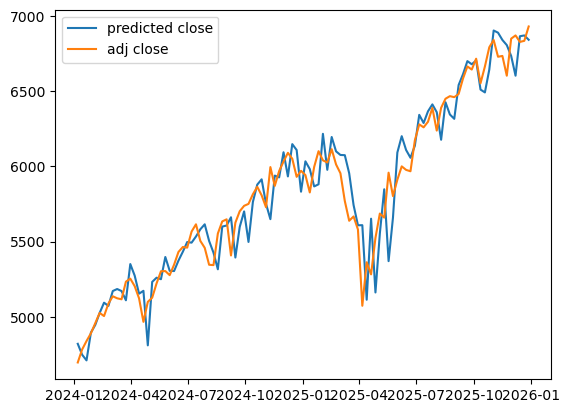

In [6]:
#draw predict close and adj close
import matplotlib.pyplot as plt
plt.plot(predicted_close,label='predicted close')
plt.plot(test['Adj Close'],label='adj close')
plt.legend()
plt.show()

In [22]:
trade_cost=0.0001
df=test.copy()

#pred return
pred_return=predicted_close.pct_change()
adj_return=pd.Series(df['Adj Close'].iloc[:, 0]).pct_change()

#only sell when predicted return lower than 0.03
weight = np.where(pred_return > 0.03,1.0,
                        np.where(pred_return > -0.05, 1.0, 0.0),)
strat_weight=pd.Series(weight,index=test.index)
#cost abs previous weight change
cost=abs(strat_weight-strat_weight.shift(1))*trade_cost
strat_return=strat_weight*adj_return-cost
strat_cumret=strat_return.cumsum().fillna(0)
adj_cumret=adj_return.cumsum().fillna(0)

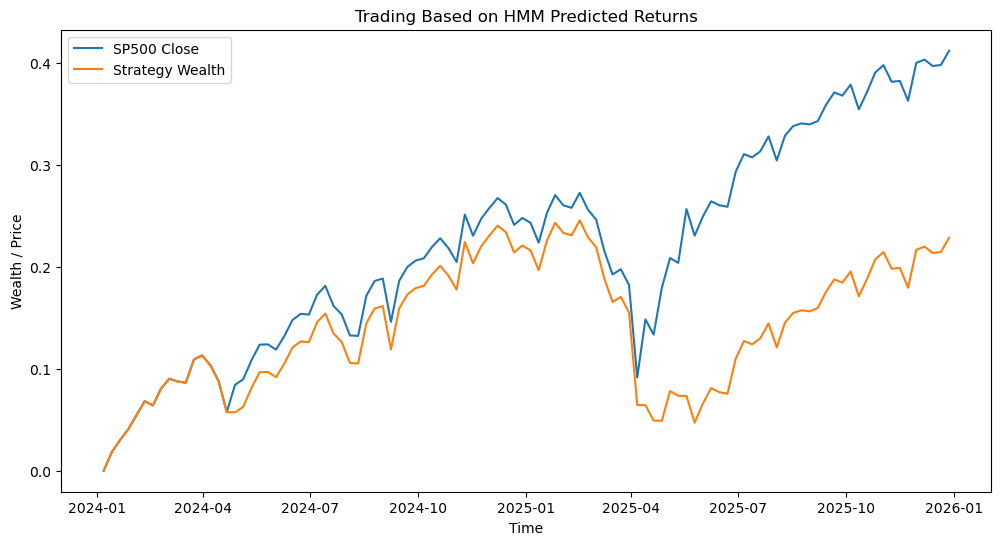

In [23]:
# compare with SP500
plt.figure(figsize=(12,6))
plt.plot(adj_cumret, label='SP500 Close')
plt.plot(strat_cumret, label='Strategy Wealth')
plt.xlabel('Time')
plt.ylabel('Wealth / Price')
plt.title('Trading Based on HMM Predicted Returns')
plt.legend()
plt.show()